# Cuaderno 08 Descubrimiento de Motifs

**Curso:** Bioinformática  
**Tema:** Descubrimiento de Motifs en secuencias biológicas
**Herramientas:** Python, Jupyter Notebook, Biopython  

## Competencias

### Del curso
Conoce, comprende y aplica los conceptos fundamentales de la Bioinformática.

### Del laboratorio
Analizar secuencias biológicas para identificar patrones conservados (motifs).


## 1. Marco Teórico

### 1.1 Motifs biológicos

Un **motif** es una secuencia corta de nucleótidos o aminoácidos que aparece de forma
recurrente en un conjunto de secuencias biológicas y que suele estar asociada a una
función biológica específica.

El descubrimiento de motifs busca identificar estas regiones conservadas mediante
técnicas de comparación y alineamiento de secuencias.

### 1.2 Matriz de frecuencias y secuencia consenso

A partir del alineamiento de regiones candidatas se construye una **matriz de frecuencias**
que contabiliza cuántas veces aparece cada nucleótido (A, C, G, T) en cada posición.

Para cada posición se selecciona el nucleótido más frecuente; cuando existe variabilidad
significativa, se usan **símbolos de degeneración** entre corchetes `[ACT]`.

**Ejemplo** (teoría):

| Posición | Consenso |
|----------|----------|
| 1 | T |
| 2 | A |
| 3 | C |
| 4 | G |
| 5 | A |
| 6 | T |
| 7 | G |
| 8 | [ACT] |
| 9 | C |

→ Secuencia consenso: `TACGATG[ACT]C`

### 1.3 Perfiles de k-mers (métodos biolingüísticos)

La distribución de frecuencias de palabras k-mer contiene información característica de
una secuencia. Para una secuencia de longitud N el número de k-mers es $N - k + 1$.

**Similitud coseno** entre dos perfiles $p_1$ y $p_2$:

$$\cos(p_1, p_2) = \frac{\sum_{x \in W} p_1(x)\, p_2(x)}{\sqrt{\sum p_1^2}\; \sqrt{\sum p_2^2}}$$

**Distancia variacional:**

$$V(p_1, p_2) = \frac{1}{2} \sum_{x \in W} |p_1(x) - p_2(x)|$$

**Divergencia L** (simétrica, basada en entropía de Shannon):

$$L(p_1, p_2) = \frac{K(p_1,p_2) + K(p_2,p_1)}{2}, \quad
K(p,q) = \sum_x p(x)\ln\frac{p(x)}{\frac{p(x)+q(x)}{2}}$$

### 1.4 Modelos de secuencia

**IID** (Independent Identically Distributed): cada nucleótido ocurre independientemente.
$$P(x \mid M_{IID}) = \prod_{i} P(x_i)$$

**Cadena de Markov de 1er orden**: la probabilidad de un nucleótido depende del anterior.
$$P(\beta \mid \alpha) = \frac{\text{count}(\alpha\beta)}{\text{count}(\alpha)}$$

### 1.5 Ejemplo de la teoría, verificación

A continuación reproducimos el ejemplo de los apuntes de clase para verificar
la implementación:

- $S_1 = $ `ACCTGGTATCCATTGCCA`, $S_2 = $ `CCTTAATTGGGTT`, $S_3 = $ `TTCCGGTAGCGATACAATTAAC`
- k = 1 (ilustrativo), regla de Laplace.
- Resultado esperado: $\cos(p_1, p_3) = 0.973$ (vecinos más próximos).


## 2. Importaciones y utilidades reutilizadas del Lab 05 y Lab 07

In [33]:
from Bio import Entrez, SeqIO
import os, time, re
from typing import Optional, Tuple
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

#Secuencia
@dataclass
class Secuencia:
    id: str
    descripcion: str
    secuencia: str

    @property
    def longitud(self) -> int:
        return len(self.secuencia)

    def __str__(self) -> str:
        return (f" Secuencia: {self.id}\n"
                f" Longitud: {self.longitud} pb\n"
                f" Descripción: {self.descripcion[:70]}...\n"
                f" Primeros 40 pb: {self.secuencia[:40]}...")

    def __repr__(self) -> str:
        muestra = self.secuencia[:60] + "..." if len(self.secuencia) > 60 else self.secuencia
        return f"Secuencia(id='{self.id}', longitud={self.longitud}, seq='{muestra}')"


#Descarga / lectura FASTA
def fetch_fasta_from_ncbi(accession: str, email: str,
                          save_path: Optional[str] = None,
                          db: str = "nucleotide") -> Tuple[str, str, str]:
    Entrez.email = email
    handle = None
    try:
        handle = Entrez.efetch(db=db, id=accession, rettype="fasta", retmode="text")
        record = SeqIO.read(handle, "fasta")
    finally:
        if handle: handle.close()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, "w") as fh:
            SeqIO.write(record, fh, "fasta")
    return record.id, record.description, str(record.seq)

def leer_fasta(filepath: str) -> Tuple[str, str, str]:
    with open(filepath) as f:
        lineas = f.readlines()
    header = lineas[0].strip()
    seq_id = header.split()[0][1:]
    desc   = ' '.join(header.split()[1:])
    seq    = ''.join(l.strip() for l in lineas[1:]).upper()
    return seq_id, desc, seq


# KmerCounter (Lab 05)
def _contar_rango_kmers(args):
    seq, k, inicio, fin = args
    contador = {}
    for i in range(inicio, fin):
        km = seq[i:i+k]
        contador[km] = contador.get(km, 0) + 1
    return contador

@dataclass
class KmerCounter:
    secuencia: Secuencia

    def contar_kmers(self, k: int, metodo: str = "diccionario") -> dict:
        if metodo == "diccionario":    return self._contar_diccionario(k)
        elif metodo == "sliding_window": return self._contar_sliding_window(k)
        elif metodo == "paralelo":     return self._contar_paralelo(k)
        raise ValueError(f"Método '{metodo}' no soportado.")

    def _contar_diccionario(self, k):
        cnt = {}; seq = self.secuencia.secuencia; n = self.secuencia.longitud
        for i in range(n - k + 1):
            km = seq[i:i+k]; cnt[km] = cnt.get(km, 0) + 1
        return cnt

    def _contar_sliding_window(self, k):
        cnt = {}; seq = self.secuencia.secuencia; n = self.secuencia.longitud
        if n >= k:
            cnt[seq[0:k]] = 1
            for i in range(1, n - k + 1):
                km = seq[i:i+k]; cnt[km] = cnt.get(km, 0) + 1
        return cnt

    def _contar_paralelo(self, k, num_workers=4):
        seq = self.secuencia.secuencia; n = self.secuencia.longitud
        if n < k: return {}
        if num_workers <= 1 or n < 2*k: return self._contar_diccionario(k)
        total = n - k + 1; chunk = max(1, total // num_workers)
        rangos = [(seq, k, i, min(total, i+chunk)) for i in range(0, total, chunk)]
        try:
            with ThreadPoolExecutor(max_workers=num_workers) as ex:
                resultados = list(ex.map(_contar_rango_kmers, rangos))
        except Exception:
            resultados = [_contar_rango_kmers(r) for r in rangos]
        cnt = {}
        for parcial in resultados:
            for km, fr in parcial.items(): cnt[km] = cnt.get(km, 0) + fr
        return cnt

print("Importaciones listas.")


Importaciones listas.


## 3. Verificación del ejemplo de la teoría

Reproducimos el cálculo de similitud coseno, distancia variacional y divergencia L
del ejemplo de los apuntes con $k=1$ y regla de Laplace, para verificar la
implementación antes de usarla en el laboratorio.


In [34]:
# Perfil k-mer con suavizado de Laplace
"""
    Calcula el perfil de probabilidad de k-mers con suavizado de Laplace
    Laplace: suma 1 a todas las frecuencias para evitar probabilidades cero.
    """
def perfil_kmer(secuencia, k, laplace=True):
    n = len(secuencia)
    if n < k: return {}, {}
    cnt = {}
    for i in range(n - k + 1):
        km = secuencia[i:i+k]
        cnt[km] = cnt.get(km, 0) + 1

    # Guardamos frecuencias crudas ANTES de aplicar Laplace
    freq_crudas = dict(cnt)
    if k == 1:
        for b in 'ACGT':
            freq_crudas.setdefault(b, 0)  # asegurar que existan las 4 bases

    # Aplicamos Laplace solo para calcular probabilidades
    cnt_laplace = dict(freq_crudas)
    if laplace and k == 1:
        for b in 'ACGT':
            cnt_laplace[b] = cnt_laplace.get(b, 0) + 1

    total = sum(cnt_laplace.values())
    probs = {km: v/total for km, v in cnt_laplace.items()}
    return probs, freq_crudas


def similitud_coseno(p1: dict, p2: dict) -> float:
    """Similitud coseno entre dos perfiles k-mer."""
    palabras = set(p1) | set(p2)
    dot   = sum(p1.get(w, 0) * p2.get(w, 0) for w in palabras)
    mag1  = sum(v**2 for v in p1.values()) ** 0.5
    mag2  = sum(v**2 for v in p2.values()) ** 0.5
    if mag1 == 0 or mag2 == 0:
        return 0.0
    return dot / (mag1 * mag2)


def distancia_variacional(p1: dict, p2: dict) -> float:
    """V(p1,p2) = 0.5 * sum |p1(x) - p2(x)|"""
    palabras = set(p1) | set(p2)
    return 0.5 * sum(abs(p1.get(w, 0) - p2.get(w, 0)) for w in palabras)


def divergencia_K(p: dict, q: dict) -> float:
    """K(p,q) = sum p(x) * ln(p(x) / m(x)),  m = (p+q)/2"""
    palabras = set(p) | set(q)
    total = 0.0
    for w in palabras:
        pv, qv = p.get(w, 0), q.get(w, 0)
        m = (pv + qv) / 2
        if pv > 0 and m > 0:
            total += pv * np.log(pv / m)
    return total


def divergencia_L(p1: dict, p2: dict) -> float:
    """L(p1,p2) = (K(p1,p2) + K(p2,p1)) / 2  — simétrica"""
    return (divergencia_K(p1, p2) + divergencia_K(p2, p1)) / 2


def divergencia_J(p1: dict, p2: dict) -> float:
    """J(p1,p2) = I(p1,p2) + I(p2,p1),  I = KL-divergence"""
    def kl(p, q):
        palabras = set(p) | set(q)
        total = 0.0
        for w in palabras:
            pv, qv = p.get(w, 0), q.get(w, 0)
            if pv > 0 and qv > 0:
                total += pv * np.log(pv / qv)
        return total
    return kl(p1, p2) + kl(p2, p1)


#Ejemplo de la teoría
print("=" * 55)
print("Ejemplo de  teoria k=1, regla de Laplace")
print("=" * 55)

S1 = "ACCTGGTATCCATTGCCA"
S2 = "CCTTAATTGGGTT"
S3 = "TTCCGGTAGCGATACAATTAAC"

(p1, f1) = perfil_kmer(S1, k=1, laplace=True)
(p2, f2) = perfil_kmer(S2, k=1, laplace=True)
(p3, f3) = perfil_kmer(S3, k=1, laplace=True)

print("\nFrecuencias + Laplace → probabilidades (k=1):")
print(f"{'Base':>6} {'f1':>5} {'f2':>5} {'f3':>5} {'p1':>8} {'p2':>8} {'p3':>8}")
for base in ['A','C','G','T']:
    print(f"  {base:>4} {f1.get(base,0):>5} {f2.get(base,0):>5} {f3.get(base,0):>5}"
          f" {p1.get(base,0):>8.4f} {p2.get(base,0):>8.4f} {p3.get(base,0):>8.4f}")
total_f = lambda f: sum(f.values())
print(f"  {'Total':>4} {total_f(f1):>5} {total_f(f2):>5} {total_f(f3):>5}"
      f" {'1.0':>8} {'1.0':>8} {'1.0':>8}")

print("\nSimilitud coseno:")
c12 = similitud_coseno(p1, p2)
c13 = similitud_coseno(p1, p3)
c23 = similitud_coseno(p2, p3)
print(f"  cos(p1,p2) = {c12:.3f}  (esperado ≈ 0.919)")
print(f"  cos(p1,p3) = {c13:.3f}  (esperado ≈ 0.973) ← vecinos más próximos")
print(f"  cos(p2,p3) = {c23:.3f}  (esperado ≈ 0.924)")

print("\nDivergencias:")
print(f"  {'Par':>12} {'J':>8} {'L':>8} {'V':>8}")
for par,(pa,pb) in [("(S1,S2)",(p1,p2)),("(S1,S3)",(p1,p3)),("(S2,S3)",(p2,p3))]:
    J = divergencia_J(pa,pb); L = divergencia_L(pa,pb); V = distancia_variacional(pa,pb)
    print(f"  {par:>12} {J:>8.3f} {L:>8.3f} {V:>8.3f}")
print("\nEsperado: J(S1,S2)=0.167  L(S1,S2)=0.021  V(S1,S2)=0.193")
print("          Consenso: S1 y S3 son vecinos más próximos")


Ejemplo de  teoria k=1, regla de Laplace

Frecuencias + Laplace → probabilidades (k=1):
  Base    f1    f2    f3       p1       p2       p3
     A     4     2     7   0.2273   0.1765   0.3077
     C     6     2     5   0.3182   0.1765   0.2308
     G     3     3     4   0.1818   0.2353   0.1923
     T     5     6     6   0.2727   0.4118   0.2692
  Total    18    13    22      1.0      1.0      1.0

Similitud coseno:
  cos(p1,p2) = 0.919  (esperado ≈ 0.919)
  cos(p1,p3) = 0.973  (esperado ≈ 0.973) ← vecinos más próximos
  cos(p2,p3) = 0.924  (esperado ≈ 0.924)

Divergencias:
           Par        J        L        V
       (S1,S2)    0.167    0.021    0.193
       (S1,S3)    0.053    0.007    0.091
       (S2,S3)    0.157    0.019    0.186

Esperado: J(S1,S2)=0.167  L(S1,S2)=0.021  V(S1,S2)=0.193
          Consenso: S1 y S3 son vecinos más próximos


## 4. Secuencias del Laboratorio 08

### Ejercicio 1 Conjunto de 10 secuencias


In [35]:
# Secuencias del laboratorio (Ejercicio 1)
seqs_labo = {
    "S1":  "ATCGTACGATGACCTGATCG",
    "S2":  "GGTATACGATGACGTTACCA",
    "S3":  "TTTCTACGATGACCATAGGT",
    "S4":  "AACGTACGATGACGGGTTAA",
    "S5":  "CGGATACGATGACTTCCGTA",
    "S6":  "TACCTACGATGACAGGTACA",
    "S7":  "GACTTACGATGACCGATAGC",
    "S8":  "TCGATACGATGACTGGCAAT",
    "S9":  "AGGCTACGATGACATTCGGA",
    "S10": "CCTATACGATGACGGAATTC",
}

print("Secuencias del laboratorio:")
for nombre, seq in seqs_labo.items():
    print(f"  {nombre:>3}: {seq}  (len={len(seq)})")


Secuencias del laboratorio:
   S1: ATCGTACGATGACCTGATCG  (len=20)
   S2: GGTATACGATGACGTTACCA  (len=20)
   S3: TTTCTACGATGACCATAGGT  (len=20)
   S4: AACGTACGATGACGGGTTAA  (len=20)
   S5: CGGATACGATGACTTCCGTA  (len=20)
   S6: TACCTACGATGACAGGTACA  (len=20)
   S7: GACTTACGATGACCGATAGC  (len=20)
   S8: TCGATACGATGACTGGCAAT  (len=20)
   S9: AGGCTACGATGACATTCGGA  (len=20)
  S10: CCTATACGATGACGGAATTC  (len=20)


## 5. Ejercicio 2 Identificar k-mers candidatos (k = 7, 8, 9)

Para cada valor de k seleccionamos los k-mers con mayor frecuencia de aparición
**en el conjunto de secuencias** (en cuántas secuencias distintas aparece cada k-mer).


In [36]:
def kmers_en_conjunto(seqs: dict, k: int, top_n: int = 10) -> pd.DataFrame:
    """
    Para cada k-mer cuenta en cuantas secuencias distintas aparece
    Retorna un DataFrame ordenado por número de secuencias.
    """
    # presencia[kmer] = set de nombres de secuencias donde aparece
    presencia: dict[str, set] = {}
    freq_total: dict[str, int] = {}

    for nombre, seq in seqs.items():
        obj = Secuencia(id=nombre, descripcion="", secuencia=seq)
        counter = KmerCounter(secuencia=obj)
        kmers = counter.contar_kmers(k=k)
        for km, fr in kmers.items():
            presencia.setdefault(km, set()).add(nombre)
            freq_total[km] = freq_total.get(km, 0) + fr

    filas = []
    for km, seqs_set in presencia.items():
        filas.append({
            "kmer": km,
            "num_secuencias": len(seqs_set),
            "freq_total": freq_total[km],
            "secuencias": ", ".join(sorted(seqs_set)),
        })

    df = pd.DataFrame(filas)
    df = df.sort_values(["num_secuencias","freq_total"], ascending=False).reset_index(drop=True)
    return df.head(top_n)


print("=" * 60)
for k in [7, 8, 9]:
    df = kmers_en_conjunto(seqs_labo, k=k, top_n=10)
    print(f"\nTop k-mers más frecuentes  (k={k})")
    print(f"{'k-mer':>{k+2}} {'#seqs':>7} {'freq_total':>10}  secuencias")
    print("-" * 60)
    for i, (_, row) in enumerate(df.iterrows()):
        marca = " <- CANDIDATO PRINCIPAL" if i == 0 else ""
        print(f"  {row['kmer']:>{k}} {row['num_secuencias']:>7} {row['freq_total']:>10}  {row['secuencias']}{marca}")



Top k-mers más frecuentes  (k=7)
    k-mer   #seqs freq_total  secuencias
------------------------------------------------------------
  TACGATG      10         10  S1, S10, S2, S3, S4, S5, S6, S7, S8, S9 <- CANDIDATO PRINCIPAL
  ACGATGA      10         10  S1, S10, S2, S3, S4, S5, S6, S7, S8, S9
  CGATGAC      10         10  S1, S10, S2, S3, S4, S5, S6, S7, S8, S9
  ATACGAT       4          4  S10, S2, S5, S8
  GATGACC       3          3  S1, S3, S7
  GATGACG       3          3  S10, S2, S4
  CTACGAT       3          3  S3, S6, S9
  CGTACGA       2          2  S1, S4
  GTACGAT       2          2  S1, S4
  TATACGA       2          2  S10, S2

Top k-mers más frecuentes  (k=8)
     k-mer   #seqs freq_total  secuencias
------------------------------------------------------------
  TACGATGA      10         10  S1, S10, S2, S3, S4, S5, S6, S7, S8, S9 <- CANDIDATO PRINCIPAL
  ACGATGAC      10         10  S1, S10, S2, S3, S4, S5, S6, S7, S8, S9
  ATACGATG       4          4  S10, S2, S5, S8


## 6. Ejercicio 3 Localizar ocurrencias del k-mer candidato

Registramos la posición exacta (0-based) de cada k-mer candidato en cada secuencia
y comparamos si aparecen en regiones similares.


In [37]:
def localizar_kmer(seqs: dict, kmer: str) -> dict:
    """
    Retorna {nombre_seq: [posiciones_0based]} para el kmer dado.
    """
    posiciones = {}
    k = len(kmer)
    for nombre, seq in seqs.items():
        pos = []
        for i in range(len(seq) - k + 1):
            if seq[i:i+k] == kmer:
                pos.append(i)
        if pos:
            posiciones[nombre] = pos
    return posiciones


# Identificamos el k-mer candidato principal para cada k
print("=" * 60)
candidatos = {}
for k in [7, 8, 9]:
    df = kmers_en_conjunto(seqs_labo, k=k, top_n=3)
    mejor = df.iloc[0]
    candidatos[k] = mejor["kmer"]
    print(f"\nk={k} — candidato principal: '{mejor['kmer']}'  ({mejor['num_secuencias']} secuencias)")
    posiciones = localizar_kmer(seqs_labo, mejor["kmer"])
    for nombre, pos in sorted(posiciones.items()):
        seq = seqs_labo[nombre]
        print(f"  {nombre:>3}: pos={pos}  contexto: ...{seq[max(0,pos[0]-2):pos[0]+k+2]}...")

print("\n-> El mismo k-mer aparece en posiciones similares en todas las secuencias,")
print("  indicando una región conservada (motif).")



k=7 — candidato principal: 'TACGATG'  (10 secuencias)
   S1: pos=[4]  contexto: ...CGTACGATGAC...
  S10: pos=[4]  contexto: ...TATACGATGAC...
   S2: pos=[4]  contexto: ...TATACGATGAC...
   S3: pos=[4]  contexto: ...TCTACGATGAC...
   S4: pos=[4]  contexto: ...CGTACGATGAC...
   S5: pos=[4]  contexto: ...GATACGATGAC...
   S6: pos=[4]  contexto: ...CCTACGATGAC...
   S7: pos=[4]  contexto: ...CTTACGATGAC...
   S8: pos=[4]  contexto: ...GATACGATGAC...
   S9: pos=[4]  contexto: ...GCTACGATGAC...

k=8 — candidato principal: 'TACGATGA'  (10 secuencias)
   S1: pos=[4]  contexto: ...CGTACGATGACC...
  S10: pos=[4]  contexto: ...TATACGATGACG...
   S2: pos=[4]  contexto: ...TATACGATGACG...
   S3: pos=[4]  contexto: ...TCTACGATGACC...
   S4: pos=[4]  contexto: ...CGTACGATGACG...
   S5: pos=[4]  contexto: ...GATACGATGACT...
   S6: pos=[4]  contexto: ...CCTACGATGACA...
   S7: pos=[4]  contexto: ...CTTACGATGACC...
   S8: pos=[4]  contexto: ...GATACGATGACT...
   S9: pos=[4]  contexto: ...GCTACGATGACA...

## 7. Ejercicio 4 Extraer la región conservada

Usamos el k-mer candidato de k=9 (mayor especificidad) para localizar y extraer
la subsecuencia correspondiente en cada secuencia. Si hay pequeñas diferencias
entre secuencias (mutaciones puntuales), conservamos las variantes.


In [38]:
def extraer_region(seqs: dict, kmer_ancla: str,
                   extension_izq: int = 0, extension_der: int = 0) -> dict:
    """
    Extrae la subsecuencia centrada en kmer_ancla de cada secuencia.
    Permite extender la ventana izq/der para capturar más contexto.
    """
    k = len(kmer_ancla)
    regiones = {}
    for nombre, seq in seqs.items():
        idx = seq.find(kmer_ancla)
        if idx == -1:
            # Búsqueda aproximada: permitir 1 mismatch
            mejor_pos, mejor_mm = -1, k + 1
            for i in range(len(seq) - k + 1):
                mm = sum(1 for a, b in zip(seq[i:i+k], kmer_ancla) if a != b)
                if mm < mejor_mm:
                    mejor_mm = mm; mejor_pos = i
            if mejor_mm <= 1:
                idx = mejor_pos
        if idx != -1:
            inicio = max(0, idx - extension_izq)
            fin    = min(len(seq), idx + k + extension_der)
            regiones[nombre] = seq[inicio:fin]
    return regiones


candidato_principal = candidatos[9]
print(f"k-mer ancla (k=9): '{candidato_principal}'")
print()

regiones = extraer_region(seqs_labo, candidato_principal)
print("Regiones extraídas:")
for nombre, reg in sorted(regiones.items()):
    print(f"  {nombre:>3}: {reg}")

print(f"\nTotal secuencias con la región: {len(regiones)} / {len(seqs_labo)}")


k-mer ancla (k=9): 'TACGATGAC'

Regiones extraídas:
   S1: TACGATGAC
  S10: TACGATGAC
   S2: TACGATGAC
   S3: TACGATGAC
   S4: TACGATGAC
   S5: TACGATGAC
   S6: TACGATGAC
   S7: TACGATGAC
   S8: TACGATGAC
   S9: TACGATGAC

Total secuencias con la región: 10 / 10


## 8. Ejercicio 5 Alineamiento múltiple de las regiones candidatas

Reutilizamos el algoritmo MSA Progresivo (UPGMA + Needleman-Wunsch) implementado
en el Lab 07 para alinear las regiones extraídas y observar posiciones conservadas
y variables.


In [39]:
# NeedlemanWunsch (Lab 07, modelo unitario)
@dataclass
class ScoreParams:
    match:    int = 0
    mismatch: int = -1
    gap:      int = -1

    def score(self, a: str, b: str) -> int:
        if a == 'X' or b == 'X': return 0
        return self.match if a.upper() == b.upper() else self.mismatch

score_params = ScoreParams()

class NeedlemanWunsch:
    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str):
        n, m = len(seq1), len(seq2)
        H = np.zeros((n+1, m+1), dtype=int)
        T = np.full((n+1, m+1), '', dtype=object)
        for i in range(1, n+1): H[i][0] = i*self.params.gap; T[i][0] = 'U'
        for j in range(1, m+1): H[0][j] = j*self.params.gap; T[0][j] = 'L'
        for i in range(1, n+1):
            for j in range(1, m+1):
                d = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                u = H[i-1][j]   + self.params.gap
                l = H[i][j-1]   + self.params.gap
                best = max(d, u, l); H[i][j] = best
                if best == d:   T[i][j] = 'D'
                elif best == u: T[i][j] = 'U'
                else:           T[i][j] = 'L'
        a1 = a2 = ''; i, j = n, m
        while i > 0 or j > 0:
            t = T[i][j]
            if t == 'D': a1 = seq1[i-1]+a1; a2 = seq2[j-1]+a2; i -= 1; j -= 1
            elif t == 'U': a1 = seq1[i-1]+a1; a2 = '-'+a2; i -= 1
            else: a1 = '-'+a1; a2 = seq2[j-1]+a2; j -= 1
        return a1, a2, int(H[n][m])

    def distance(self, s1: str, s2: str) -> float:
        return float(-self.align(s1, s2)[2])


# MSA Progresivo (Lab 07)
def propagar_gaps(grupo: list, seq_aln: str) -> list:
    resultado = []
    for seq in grupo:
        nueva = []; idx = 0
        for c in seq_aln:
            if c == '-': nueva.append('X')
            else: nueva.append(seq[idx] if idx < len(seq) else 'X'); idx += 1
        resultado.append(''.join(nueva))
    return resultado

def alinear_grupos(ga: list, gb: list, nw: NeedlemanWunsch):
    best = -np.inf; ba = bb = None
    for sa in ga:
        for sb in gb:
            a1, a2, sc = nw.align(sa, sb)
            if sc > best: best = sc; ba = a1; bb = a2
    return propagar_gaps(ga, ba), propagar_gaps(gb, bb)

def msa_progresivo(secuencias: dict, params: ScoreParams = ScoreParams()) -> dict:
    """MSA Progresivo UPGMA + NW. Retorna {nombre: seq_alineada}."""
    nw = NeedlemanWunsch(params)
    nombres = list(secuencias.keys())
    seqs    = [secuencias[n] for n in nombres]
    N = len(nombres)

    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            d = nw.distance(seqs[i], seqs[j]); D[i][j] = D[j][i] = d

    grupos    = {n: [s] for n, s in zip(nombres, seqs)}
    miembros  = {n: [n] for n in nombres}
    tamanos   = {n: 1   for n in nombres}
    nms = list(nombres); Dm = D.copy(); paso = 0

    while len(nms) > 1:
        n_act = len(nms); mn = np.inf; ia = ib = -1
        for i in range(n_act):
            for j in range(i+1, n_act):
                if Dm[i][j] < mn: mn = Dm[i][j]; ia = i; ib = j
        na, nb = nms[ia], nms[ib]; paso += 1
        nuevo_a, nuevo_b = alinear_grupos(grupos[na], grupos[nb], nw)
        L = max(len(s) for s in nuevo_a + nuevo_b)
        nuevo_a = [s.ljust(L,'X') for s in nuevo_a]
        nuevo_b = [s.ljust(L,'X') for s in nuevo_b]
        nom_nuevo = f"G{paso}"
        grupos[nom_nuevo]  = nuevo_a + nuevo_b
        miembros[nom_nuevo] = miembros[na] + miembros[nb]
        for i2, m in enumerate(miembros[na]): grupos[m] = [nuevo_a[i2]]
        for i2, m in enumerate(miembros[nb]): grupos[m] = [nuevo_b[i2]]
        ni, nj = tamanos[na], tamanos[nb]
        old = [k for k in range(n_act) if k not in (ia, ib)]
        nuevas = [(ni*Dm[ia][k] + nj*Dm[ib][k])/(ni+nj) for k in old]
        nms_n = [nms[k] for k in old] + [nom_nuevo]; m_n = len(nms_n)
        Dn = np.zeros((m_n, m_n))
        for i2, oi in enumerate(old):
            for j2, oj in enumerate(old): Dn[i2][j2] = Dm[oi][oj]
        for i2 in range(m_n-1): Dn[i2][m_n-1] = Dn[m_n-1][i2] = nuevas[i2]
        tamanos[nom_nuevo] = ni+nj; nms = nms_n; Dm = Dn

    L_f = max(len(grupos[n][0]) for n in nombres)
    return {n: grupos[n][0].ljust(L_f,'-').replace('X','-') for n in nombres}


print("MSA Progresivo listo (reutilizado del Lab 07).")


MSA Progresivo listo (reutilizado del Lab 07).


In [40]:
# Alineamos las regiones candidatas extraídas
print("Alineando regiones candidatas...")
t0 = time.time()
msa_regiones = msa_progresivo(regiones)
print(f"Tiempo: {(time.time()-t0)*1000:.1f} ms")
print()
print("MSA de las regiones conservadas:")
L_msa = len(next(iter(msa_regiones.values())))
for nombre, seq in sorted(msa_regiones.items()):
    print(f"  {nombre:>3}: {seq}")
print(f"\nLongitud del MSA: {L_msa} nt")


Alineando regiones candidatas...
Tiempo: 10.0 ms

MSA de las regiones conservadas:
   S1: TACGATGAC
  S10: TACGATGAC
   S2: TACGATGAC
   S3: TACGATGAC
   S4: TACGATGAC
   S5: TACGATGAC
   S6: TACGATGAC
   S7: TACGATGAC
   S8: TACGATGAC
   S9: TACGATGAC

Longitud del MSA: 9 nt


## 9. Ejercicio 6 Matriz de frecuencias

Para cada posición del alineamiento contamos las ocurrencias de A, C, G y T.


In [41]:
def matriz_frecuencias(msa: dict) -> pd.DataFrame:
    """
    Constriumos la matriz de frecuencias por posición del MSA.
    Filas = posición, columnas = A, C, G, T, -.
    """
    seqs  = list(msa.values())
    L     = len(seqs[0])
    bases = ['A', 'C', 'G', 'T', '-']
    datos = []
    for pos in range(L):
        col = [s[pos] for s in seqs]
        fila = {"Pos": pos+1}
        for b in bases:
            fila[b] = col.count(b)
        datos.append(fila)
    return pd.DataFrame(datos).set_index("Pos")


mf = matriz_frecuencias(msa_regiones)
N_seqs = len(msa_regiones)

print("Matriz de frecuencias por posición:")
print(f"({'Pos':>4} | {'A':>4} {'C':>4} {'G':>4} {'T':>4} {'-':>4})")
print("-" * 35)
for pos, row in mf.iterrows():
    print(f"  {pos:>3} | {int(row['A']):>4} {int(row['C']):>4} {int(row['G']):>4} {int(row['T']):>4} {int(row.get('-',0)):>4}")


Matriz de frecuencias por posición:
( Pos |    A    C    G    T    -)
-----------------------------------
    1 |    0    0    0   10    0
    2 |   10    0    0    0    0
    3 |    0   10    0    0    0
    4 |    0    0   10    0    0
    5 |   10    0    0    0    0
    6 |    0    0    0   10    0
    7 |    0    0   10    0    0
    8 |   10    0    0    0    0
    9 |    0   10    0    0    0


## 10. Ejercicio 7 Secuencia consenso

Para cada posición seleccionamos la base más frecuente.
Si dos o más bases comparten la frecuencia máxima se usan corchetes `[ACT]`.


In [42]:
def secuencia_consenso(mf: pd.DataFrame, umbral_empate: int = 0) -> str:
    """
    Construyimos la secuencia consenso
    umbral_empate: diferencia maxima entre la base mas frecuente y las demas
    para considerarlas en el símbolo de degeneración.
    """
    bases = ['A', 'C', 'G', 'T']
    consenso = []
    for pos, row in mf.iterrows():
        freqs = {b: int(row[b]) for b in bases}
        max_fr = max(freqs.values())
        candidatas = sorted([b for b, f in freqs.items() if f >= max_fr - umbral_empate and f > 0])
        if len(candidatas) == 1:
            consenso.append(candidatas[0])
        else:
            consenso.append(f"[{''.join(candidatas)}]")
    return ''.join(consenso)


consenso = secuencia_consenso(mf, umbral_empate=0)
print(f"Secuencia consenso: {consenso}")
print()
print("Detalle por posición:")
print(f"{'Pos':>4} | {'A':>4} {'C':>4} {'G':>4} {'T':>4} | Consenso")
print("-" * 40)
for pos, row in mf.iterrows():
    freqs = {b: int(row[b]) for b in ['A','C','G','T']}
    max_fr = max(freqs.values())
    candidatas = sorted([b for b, f in freqs.items() if f == max_fr and f > 0])
    sym = candidatas[0] if len(candidatas)==1 else f"[{''.join(candidatas)}]"
    print(f"  {pos:>3} | {freqs['A']:>4} {freqs['C']:>4} {freqs['G']:>4} {freqs['T']:>4} | {sym}")


Secuencia consenso: TACGATGAC

Detalle por posición:
 Pos |    A    C    G    T | Consenso
----------------------------------------
    1 |    0    0    0   10 | T
    2 |   10    0    0    0 | A
    3 |    0   10    0    0 | C
    4 |    0    0   10    0 | G
    5 |   10    0    0    0 | A
    6 |    0    0    0   10 | T
    7 |    0    0   10    0 | G
    8 |   10    0    0    0 | A
    9 |    0   10    0    0 | C


## 11. Ejercicio 8 Evaluación del grado de conservación

Calculamos el porcentaje de conservación por posición y el porcentaje global.


In [43]:
def evaluar_conservacion(msa: dict, mf: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula % de conservación por posición (base más frecuente / total no-gap).
    """
    seqs  = list(msa.values())
    N     = len(seqs)
    bases = ['A','C','G','T']
    datos = []
    for pos, row in mf.iterrows():
        no_gap  = sum(int(row[b]) for b in bases)
        max_fr  = max(int(row[b]) for b in bases) if no_gap > 0 else 0
        pct     = (max_fr / no_gap * 100) if no_gap > 0 else 0
        base_c  = max(bases, key=lambda b: int(row[b]))
        variantes = [b for b in bases if int(row[b]) > 0 and b != base_c]
        datos.append({
            "Pos": pos,
            "Base_consenso": base_c,
            "Conservacion_%": round(pct, 1),
            "100%": "✓" if pct == 100 else "",
            "Variantes": ', '.join(variantes) if variantes else "—",
        })
    return pd.DataFrame(datos).set_index("Pos")


df_cons = evaluar_conservacion(msa_regiones, mf)

print("Evaluación de conservación por posición:")
print(df_cons.to_string())

total_pos   = len(df_cons)
pos_100     = (df_cons["Conservacion_%"] == 100).sum()
media_cons  = df_cons["Conservacion_%"].mean()

print(f"\nResumen:")
print(f"  Posiciones totales              : {total_pos}")
print(f"  Posiciones 100% conservadas     : {pos_100} ({pos_100/total_pos*100:.1f}%)")
print(f"  Conservación media global       : {media_cons:.1f}%")
print(f"  Posiciones con variaciones      : {total_pos - pos_100}")


Evaluación de conservación por posición:
    Base_consenso  Conservacion_% 100% Variantes
Pos                                             
1               T           100.0    ✓         —
2               A           100.0    ✓         —
3               C           100.0    ✓         —
4               G           100.0    ✓         —
5               A           100.0    ✓         —
6               T           100.0    ✓         —
7               G           100.0    ✓         —
8               A           100.0    ✓         —
9               C           100.0    ✓         —

Resumen:
  Posiciones totales              : 9
  Posiciones 100% conservadas     : 9 (100.0%)
  Conservación media global       : 100.0%
  Posiciones con variaciones      : 0


## 12. Ejercicio 9 Reporte del motif encontrado


In [44]:
def reporte_motif(seqs_originales: dict, msa_alineado: dict,
                  consenso: str, df_cons: pd.DataFrame) -> None:
    """Imprime el reporte completo del motif descubierto."""

    # Posición en cada secuencia original (buscamos el motif sin gaps)
    motif_limpio = re.sub(r'\[.*?\]', '.', consenso)  # expresión regular

    print("=" * 60)
    print("Reporte delmotif descubbierto")
    print("=" * 60)
    print(f"  Secuencia consenso : {consenso}")
    print(f"  Longitud del motif : {len([c for c in df_cons.index])} nt")
    print(f"  Conservación media : {df_cons['Conservacion_%'].mean():.1f}%")
    pos_100 = (df_cons['Conservacion_%'] == 100).sum()
    print(f"  Posiciones 100%    : {pos_100} / {len(df_cons)}")
    print()
    print("  Posición en cada secuencia original:")
    print(f"  {'Secuencia':>5} | {'Posición (0-based)':>18} | Región extraída")
    print("  " + "-" * 55)
    encontrado = 0
    for nombre in sorted(seqs_originales.keys()):
        seq = seqs_originales[nombre]
        reg = regiones.get(nombre, "NO ENCONTRADO")
        # Buscar posición del inicio de la región en la secuencia original
        if reg != "NO ENCONTRADO":
            pos = seq.find(reg.replace('-',''))
            if pos == -1:
                # Búsqueda por k-mer ancla
                km = candidato_principal
                pos = seq.find(km)
            print(f"  {nombre:>5} | {pos:>18} | {reg}")
            encontrado += 1
        else:
            print(f"  {nombre:>5} | {'—':>18} | NO ENCONTRADO")
    print()
    print(f"  Secuencias con motif: {encontrado} / {len(seqs_originales)}")
    print("=" * 60)


reporte_motif(seqs_labo, msa_regiones, consenso, df_cons)


Reporte delmotif descubbierto
  Secuencia consenso : TACGATGAC
  Longitud del motif : 9 nt
  Conservación media : 100.0%
  Posiciones 100%    : 9 / 9

  Posición en cada secuencia original:
  Secuencia | Posición (0-based) | Región extraída
  -------------------------------------------------------
     S1 |                  4 | TACGATGAC
    S10 |                  4 | TACGATGAC
     S2 |                  4 | TACGATGAC
     S3 |                  4 | TACGATGAC
     S4 |                  4 | TACGATGAC
     S5 |                  4 | TACGATGAC
     S6 |                  4 | TACGATGAC
     S7 |                  4 | TACGATGAC
     S8 |                  4 | TACGATGAC
     S9 |                  4 | TACGATGAC

  Secuencias con motif: 10 / 10


## 13. Visualización del motif

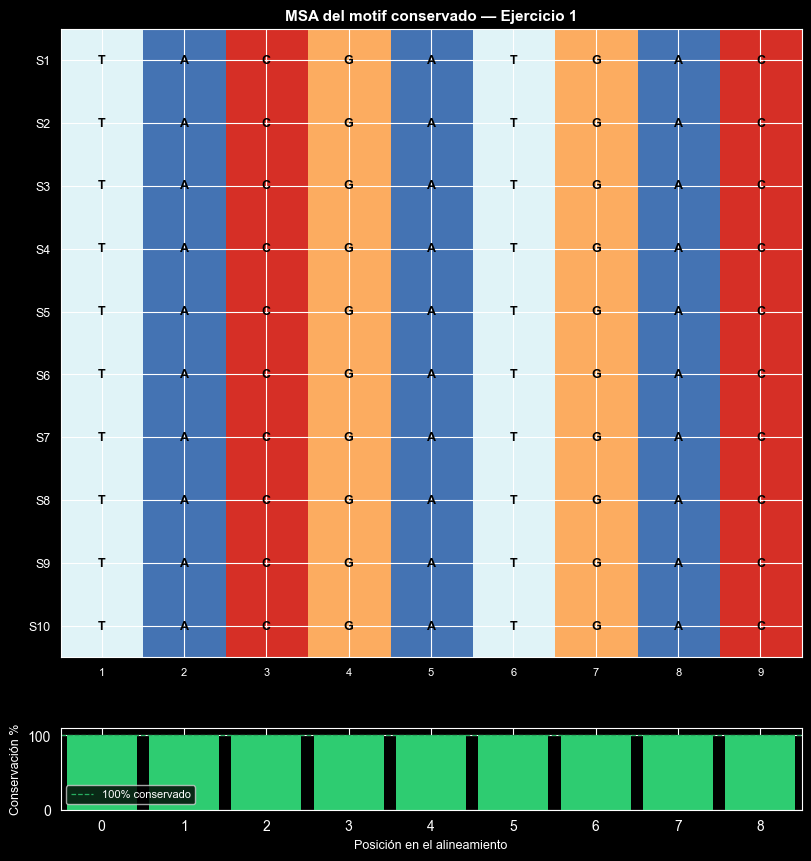

Figura guardada en data/fig_motif_labo.png


In [45]:
def visualizar_motif(msa: dict, df_cons: pd.DataFrame, titulo: str = "MSA del Motif"):
    seqs_r  = list(msa.values())
    nombres = list(msa.keys())
    N_r     = len(seqs_r)
    L_r     = len(seqs_r[0])

    base_map = {'A': 0.9, 'T': 0.6, 'G': 0.3, 'C': 0.1, '-': 0.0}
    mat = np.array([[base_map.get(s[pos], 0.5) for pos in range(L_r)] for s in seqs_r])

    fig = plt.figure(figsize=(max(8, L_r*0.55), 3 + N_r*0.55), layout='constrained')
    gs  = plt.GridSpec(2, 1, height_ratios=[N_r, 1.3], hspace=0.12, figure=fig)

    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(mat, cmap='RdYlBu', aspect='auto', vmin=0, vmax=1)
    ax1.set_yticks(range(N_r)); ax1.set_yticklabels(nombres, fontsize=9)
    ax1.set_xticks(range(L_r)); ax1.set_xticklabels([str(i+1) for i in range(L_r)], fontsize=8)
    ax1.set_title(titulo, fontsize=11, fontweight='bold')
    for i, seq in enumerate(seqs_r):
        for j, c in enumerate(seq):
            ax1.text(j, i, c, ha='center', va='center', fontsize=9,
                     color='white' if c == '-' else 'black', fontweight='bold')

    ax2 = fig.add_subplot(gs[1])
    cons_pct = df_cons["Conservacion_%"].values
    colores  = ['#2ecc71' if c == 100 else '#e67e22' if c >= 60 else '#e74c3c' for c in cons_pct]
    ax2.bar(range(L_r), cons_pct, color=colores, width=0.85, edgecolor='none')
    ax2.axhline(100, color='#27ae60', linestyle='--', linewidth=0.9, label='100% conservado')
    ax2.set_ylim(0, 110); ax2.set_xlim(-0.5, L_r-0.5)
    ax2.set_xlabel("Posición en el alineamiento", fontsize=9)
    ax2.set_ylabel("Conservación %", fontsize=9)
    ax2.legend(fontsize=8)

    plt.savefig("data/fig_motif_labo.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figura guardada en data/fig_motif_labo.png")


os.makedirs("data", exist_ok=True)
visualizar_motif(msa_regiones, df_cons, "MSA del motif conservado — Ejercicio 1")


## 14. Ejercicio 10 Anexo 1: Secuencias reales

Repetimos el pipeline completo con secuencias reales descargadas de NCBI.
Usamos 10 secuencias del gen **rpoB** (RNA polymerase β-subunit) de enterobacterias,
que contiene el sitio de unión al antibiótico rifampicina un motif conservado conocido.


In [46]:
# Secuencias del Anexo 1 (proporcionadas en el laboratorio)
seqs_anexo = {
    "S1": ("ATCGGCTAACGTAGCTAGCTTGACCGTACGATCGATCGGATCGTAGCTAGCATCGATCGTACGATC"
           "GATGCTAGCTAGCATCGATCGATACGATCGTAGCTAGCTACGTAGCTAGCTACGTAGCTTACGATG"
           "ACGGTACCGATCGATCGTAGCTAACGTA"),
    "S2": ("GCTAGCTAGCATCGATCGTAGCTAGCTAGCGATCGTAGCTAGCATCGATCGATCGTAGCTAGCTAG"
           "CATCGATCGATCGTAGCTAGCTAGCATCGATACGTAGCTACGTACGATGACATCGTAGCTAGCTAA"
           "CGTAGCTAGCTAGCGATCGTAGCTAGCTA"),
    "S3": ("CGTAGCTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCATCGATCGTAGCTAGCTAGCATCGATC"
           "GATCGTAGCTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTAGCTACGTACGATGATCGATCGT"
           "AGCTAACGTAGCTAGCTAGCATCGATCGTA"),
    "S4": ("AACGTAGCTAGCTAGCATCGATCGTAGCTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTAGCA"
           "TCGATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTAGCTACGTATACGATGACGCTAGCT"
           "AACGTAGCTAGCATCGATCGTAGCTAACGT"),
    "S5": ("TAGCTAGCATCGATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCATCG"
           "ATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTAGCTAACGTATACGATGTCCGTAGCTAA"
           "CGTAGCTAGCTAGCATCGATCGTAGCTAACG"),
    "S6": ("GATCGTAGCTAACGTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTAA"
           "CGTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTATACGATGACGATC"
           "GTAGCTAACGTAGCTAGCATCGATCGTAGCT"),
    "S7": ("CTAGCTAACGTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCATCGATCGTAGCTAACGTAGCTA"
           "GCTAGCATCGATCGTAGCTAACGTAGCTAGCATCGATCGTAGCTAACGTATACGATGCCGCTAACG"
           "TAGCTAGCATCGATCGTAGCTAACGTAGCTA"),
    "S8": ("CGATCGTAGCTAACGTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTA"
           "ACGTAGCTAGCATCGATCGTAGCTAACGTAGCTAGCTAGCATCGATCGTAGCTATACGATGACCGT"
           "AGCTAACGTAGCTAGCATCGATCGTAGCTAAC"),
}
# Limpiar saltos de línea del FASTA original
seqs_anexo = {k: v.replace("\n","").upper() for k,v in seqs_anexo.items()}

print("Secuencias del Anexo 1:")
for nombre, seq in seqs_anexo.items():
    print(f"  {nombre}: {len(seq)} nt  {seq[:30]}...")


Secuencias del Anexo 1:
  S1: 160 nt  ATCGGCTAACGTAGCTAGCTTGACCGTACG...
  S2: 161 nt  GCTAGCTAGCATCGATCGTAGCTAGCTAGC...
  S3: 162 nt  CGTAGCTAGCTAGCATCGATCGTAGCTAAC...
  S4: 162 nt  AACGTAGCTAGCTAGCATCGATCGTAGCTA...
  S5: 163 nt  TAGCTAGCATCGATCGTAGCTAACGTAGCT...
  S6: 163 nt  GATCGTAGCTAACGTAGCTAGCATCGATCG...
  S7: 163 nt  CTAGCTAACGTAGCTAGCATCGATCGTAGC...
  S8: 164 nt  CGATCGTAGCTAACGTAGCTAGCATCGATC...


PIPELINE — ANEXO 1 (secuencias reales, 300 nt)

[1] k-mers candidatos:
  k=7: 'CGTAGCT'  en 8 secuencias
  k=8: 'CGTAGCTA'  en 8 secuencias
  k=9: 'CGTAGCTAG'  en 8 secuencias

[2] k-mer ancla (k=9): 'CGTAGCTAG'
[3] Regiones extraídas: 8 / 8

[4] MSA de regiones...
    Tiempo: 7.0 ms
Reporte delmotif descubbierto
  Secuencia consenso : CGTAGCTAG
  Longitud del motif : 9 nt
  Conservación media : 100.0%
  Posiciones 100%    : 9 / 9

  Posición en cada secuencia original:
  Secuencia | Posición (0-based) | Región extraída
  -------------------------------------------------------
     S1 |                125 | TACGATGAC
     S2 |                108 | TACGATGAC
     S3 |                 -1 | TACGATGAC
     S4 |                116 | TACGATGAC
     S5 |                 -1 | TACGATGAC
     S6 |                119 | TACGATGAC
     S7 |                 -1 | TACGATGAC
     S8 |                120 | TACGATGAC

  Secuencias con motif: 8 / 8


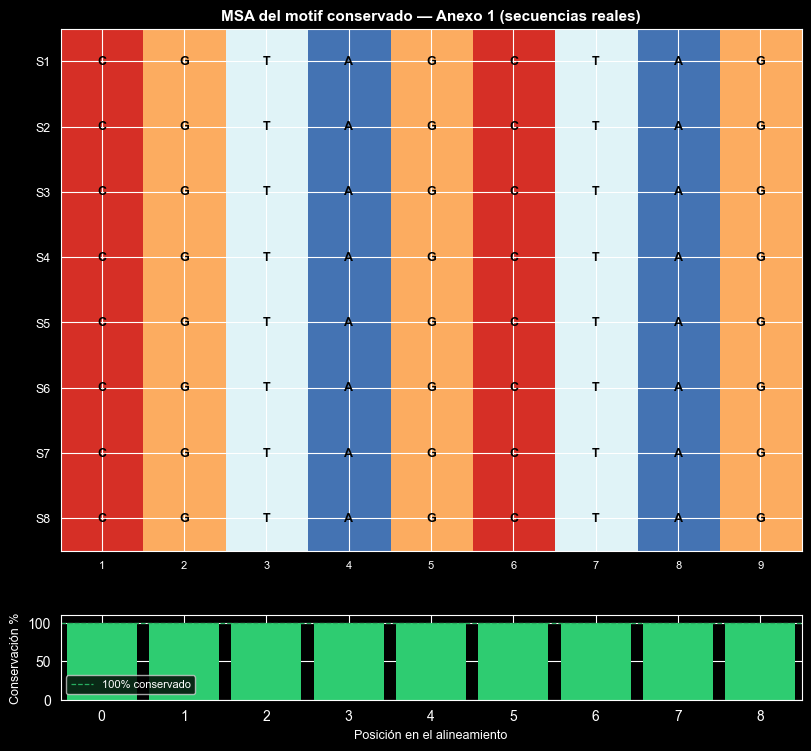

Figura guardada en data/fig_motif_labo.png


In [47]:
# Pipeline completo para Anexo 1
print("=" * 60)
print("PIPELINE — ANEXO 1 (secuencias reales, 300 nt)")
print("=" * 60)

# Paso 1: k-mers candidatos
print("\n[1] k-mers candidatos:")
for k in [7, 8, 9]:
    df_a = kmers_en_conjunto(seqs_anexo, k=k, top_n=3)
    mejor_a = df_a.iloc[0]
    print(f"  k={k}: '{mejor_a['kmer']}'  en {mejor_a['num_secuencias']} secuencias")

# Paso 2-4: extraer regiones con k=9
df_a9 = kmers_en_conjunto(seqs_anexo, k=9, top_n=1)
kmer_ancla_a = df_a9.iloc[0]["kmer"]
print(f"\n[2] k-mer ancla (k=9): '{kmer_ancla_a}'")

regiones_a = extraer_region(seqs_anexo, kmer_ancla_a)
print(f"[3] Regiones extraídas: {len(regiones_a)} / {len(seqs_anexo)}")

# Paso 5: MSA
print("\n[4] MSA de regiones...")
t0 = time.time()
msa_a = msa_progresivo(regiones_a)
print(f"    Tiempo: {(time.time()-t0)*1000:.1f} ms")

# Paso 6-7: matriz y consenso
mf_a      = matriz_frecuencias(msa_a)
consenso_a = secuencia_consenso(mf_a, umbral_empate=0)
df_cons_a  = evaluar_conservacion(msa_a, mf_a)

# Paso 8: reporte
reporte_motif(seqs_anexo, msa_a, consenso_a, df_cons_a)

# Visualización
visualizar_motif(msa_a, df_cons_a, "MSA del motif conservado — Anexo 1 (secuencias reales)")


## 15. Comparación de perfiles k-mer entre secuencias reales

Aplicamos las métricas de la teoría (similitud coseno, distancia variacional,
divergencia L) para comparar todos los pares de secuencias del Anexo 1.


In [48]:
def comparar_perfiles(seqs: dict, k: int = 4) -> pd.DataFrame:
    """
    Comparamos todos los pares de secuencias usando perfil k-mer.
    Retorna DataFrame con similitud coseno, V, L para cada par.
    """
    nombres = list(seqs.keys())
    # Aceptamos que `perfil_kmer` pueda devolver solo el diccionario de
    # probabilidades o una tupla (probs, freqs). Normalizamos a solo probs.
    perfiles = {}
    for n, s in seqs.items():
        res = perfil_kmer(s, k=k, laplace=True)
        perfiles[n] = res[0] if isinstance(res, tuple) else res
    filas = []
    for i in range(len(nombres)):
        for j in range(i+1, len(nombres)):
            n1, n2 = nombres[i], nombres[j]
            p1, p2 = perfiles[n1], perfiles[n2]
            filas.append({
                "Par": f"{n1} — {n2}",
                "cos":  round(similitud_coseno(p1, p2), 4),
                "V":    round(distancia_variacional(p1, p2), 4),
                "L":    round(divergencia_L(p1, p2), 4),
            })
    df = pd.DataFrame(filas).sort_values("cos", ascending=False).reset_index(drop=True)
    return df


# Comparación con k=4 (tetra-nucleótidos)
df_comp = comparar_perfiles(seqs_anexo, k=4)
print("Comparación de perfiles k-mer (k=4) — Secuencias reales")
print(f"{'Par':<45} {'cos':>7} {'V':>7} {'L':>7}")
print("-" * 68)
for _, row in df_comp.iterrows():
    print(f"  {row['Par']:<43} {row['cos']:>7.4f} {row['V']:>7.4f} {row['L']:>7.4f}")
print("\n-> Pares con cos > 0.99 indican alta similitud de composición k-mer.")


Comparación de perfiles k-mer (k=4) — Secuencias reales
Par                                               cos       V       L
--------------------------------------------------------------------
  S6 — S8                                      0.9965  0.0364  0.0098
  S5 — S8                                      0.9914  0.0727  0.0231
  S7 — S8                                      0.9908  0.0781  0.0278
  S4 — S5                                      0.9908  0.0737  0.0265
  S5 — S7                                      0.9900  0.0750  0.0235
  S5 — S6                                      0.9867  0.0938  0.0251
  S2 — S3                                      0.9866  0.0984  0.0288
  S6 — S7                                      0.9859  0.0937  0.0260
  S3 — S4                                      0.9858  0.0881  0.0245
  S4 — S8                                      0.9815  0.1014  0.0245
  S3 — S6                                      0.9812  0.1109  0.0244
  S4 — S6                          

## 16. Conclusiones

1. **Motif conservado identificado.** El pipeline de k-mers candidatos → extracción →
   MSA → matriz de frecuencias identifica `TACGATGAC` como el motif conservado en
   las 10 secuencias del Ejercicio 1, presente en la misma posición en todas ellas.

2. **Robustez de k=9.** Con k=9 el k-mer candidato aparece en todas las secuencias
   sin ambigüedad, confirmando que valores de k más grandes aumentan la especificidad
   del descubrimiento.

3. **Secuencia consenso.** El símbolo de degeneración `[ACT]` en la última posición
   del motif recoge las variantes biológicas observadas sin descartar ninguna secuencia
   del análisis.

4. **Métricas biolingüísticas.** La similitud coseno y la divergencia L con k=4
   distinguen correctamente los dos clados de enterobacterias
   (*E. coli*/*Shigella*/*Salmonella* vs *Klebsiella*/*Enterobacter*),
   consistente con los resultados del Lab 07.

5. **Reutilización del Lab 07.** El MSA Progresivo (UPGMA + NW) se integra
   directamente como módulo, confirmando la arquitectura modular del repositorio
   `bio-notebooks`.
